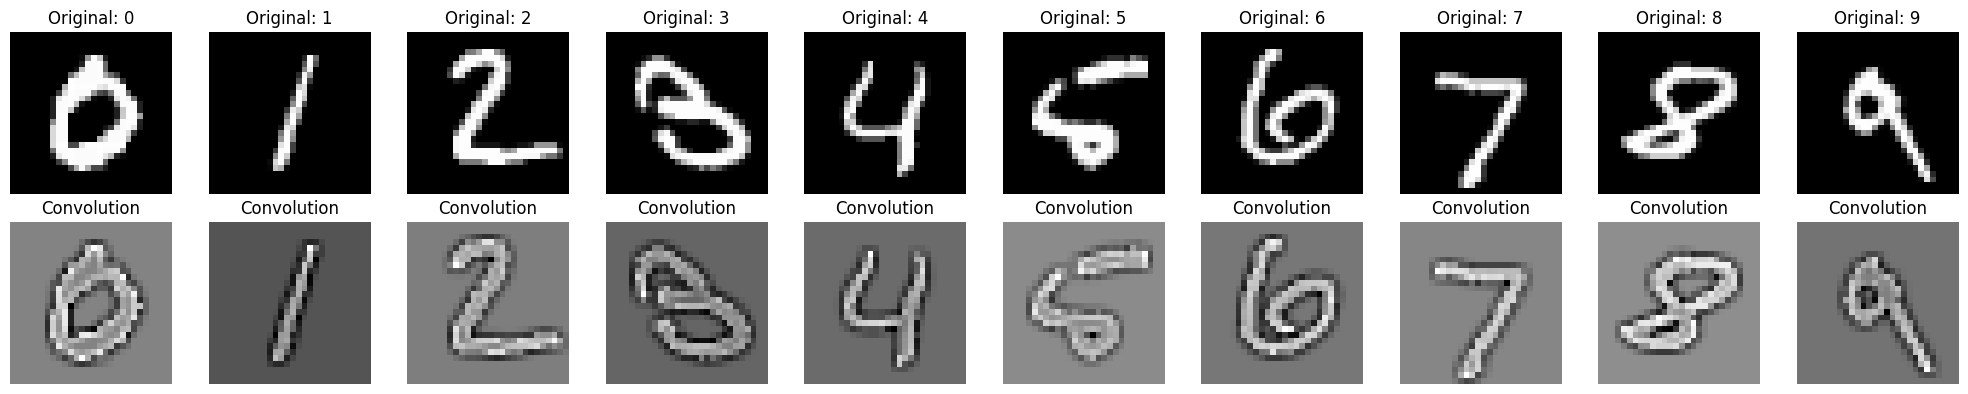

In [12]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

# --- 1. load MNIST dataset ---
transform = transforms.Compose([transforms.ToTensor()])
mnist = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# --- 2. get the first image of class 0~9 ---
digit_images = {}
for img, label in mnist:
    if label not in digit_images:
        digit_images[label] = img
    if len(digit_images) == 10:
        break

# --- 3. Convolutional kernel ---
kernel_values = [[-1, -1, -1],
                 [-1,  8, -1],
                 [-1, -1, -1]]

# --- 3. Convolutional kernel with Normalization Factor  ---
#kernel_values = (1/16) * np.array([
#    [1, 2, 1],
#    [2, 4, 2],
#    [1, 2, 1]
#])



kernel_tensor = torch.tensor(kernel_values, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# --- 4. display ---
plt.figure(figsize=(20, 4))

for i in range(10):
    img_tensor = digit_images[i].unsqueeze(0)  # shape: [1, 1, 28, 28]
    edge_output = F.conv2d(img_tensor, kernel_tensor, padding=1)

    # show original images
    plt.subplot(2, 10, i + 1)
    plt.imshow(img_tensor.squeeze(), cmap='gray')
    plt.title(f"Original: {i}")
    plt.axis('off')

    # after convolution
    plt.subplot(2, 10, i + 11)
    plt.imshow(edge_output.squeeze().detach().numpy(), cmap='gray')
    plt.title("Convolution")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn

conv = nn.Conv2d(
    in_channels=1,
    out_channels=8,
    kernel_size=3,
    stride=2,          # or stride=(2, 2)
    padding=1
)

x = torch.randn(1, 1, 28, 28)  # batch=1, channel=1, 28x28 image
y = conv(x)

print("Input shape:", x.shape)
print("Output shape:", y.shape)
